## Crawling Data Detik.com

Pada bagian ini, kita akan berlatih melakukan proses pengambilan data (*web crawling*) dengan mengumpulkan judul-judul berita olahraga terkini dari situs **Detik Health**.

Untuk melakukan ekstraksi data ini, terdapat tiga *library* utama yang akan digunakan:
* **Requests:** Berfungsi untuk mengirimkan permintaan (HTTP Request) ke server website dan mengambil kode HTML mentah darinya.
* **BeautifulSoup:** Berfungsi untuk mengurai dan menyusun struktur HTML sehingga elemen-elemen tertentu (seperti teks judul dan link) dapat dipilah dengan mudah.
* **Pandas:** Berfungsi untuk mengorganisir hasil data yang telah diekstrak ke dalam bentuk tabel (*DataFrame*) yang terstruktur rapi.

In [1]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

# 1. Menentukan URL target (Detik Sport) dan Headers
url = 'https://health.detik.com/indeks'
headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/114.0.0.0 Safari/537.36'
}

# 2. Mengambil konten HTML dari website
response = requests.get(url, headers=headers)
soup = BeautifulSoup(response.text, 'html.parser')

# 3. Mencari semua blok artikel berita
articles = soup.find_all('article')
data_berita = []

# 4. Mengekstrak judul dan tautan dari masing-masing artikel
for article in articles:
    title_tag = article.find('h3')
    link_tag = article.find('a')
    
    if title_tag and link_tag:
        judul = title_tag.get_text(strip=True)
        tautan = link_tag['href']
        
        data_berita.append({
            'Judul Berita': judul,
            'Tautan': tautan
        })

# 5. Menampilkan hasil dalam bentuk tabel Pandas
df_berita = pd.DataFrame(data_berita)
df_berita.head(10) # Menampilkan 10 berita teratas

,Judul Berita,Tautan
0,"Penampakan Gumpalan Rambut 1,5 Kg yang Diangka...",https://health.detik.com/fotohealth/d-8656417/...
1,Ternyata Manusia Masih Bisa Hidup Tanpa 5 Orga...,https://health.detik.com/berita-detikhealth/d-...
2,"Viral Makan Jahe Mentah Biar Nggak Flu, Dokter...",https://health.detik.com/berita-detikhealth/d-...
3,"Wanita Texas Rayakan Ultah ke-105, Ungkap Raha...",https://health.detik.com/berita-detikhealth/d-...
4,"Jalan Cepat Vs Jumlah Langkah 10 Ribu Sehari, ...",https://health.detik.com/kebugaran/d-8656115/j...
5,Video: Pengakses Healing 119 Capai 600 per Shi...,https://20.detik.com/detikupdate/20260909-2609...
6,Video: Kemenkes soal Siswi di Karo Diduga Hila...,https://20.detik.com/detikupdate/20260909-2609...
7,Video Kemenkes: Kasus Bunuh Diri RI Naik Tiap ...,https://20.detik.com/detikupdate/20260909-2609...
8,Video Kemenkes Ungkap Masalah Keluarga Pemicu ...,https://health.detik.com/detiktv/d-8656064/vid...
9,"Waspada, 7 Makanan Ini Diam-diam Ganggu Keseha...",https://health.detik.com/berita-detikhealth/d-...


Data tabular di atas merupakan hasil akhir dari proses pengumpulan informasi mentah pada halaman indeks. Setelah dikumpulkan dalam format tabel seperti ini, dataset sudah siap untuk dibersihkan dan diproses lebih lanjut pada tahap prapemrosesan teks (*text preprocessing*) dalam siklus Web Mining.

In [1]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import re
from urllib.parse import urljoin

headers = {
    'User-Agent': 'Mozilla/5.0'
}

url = 'https://health.detik.com/indeks'

data_berita = []

# Maksimal 10 halaman
for halaman in range(10):

    print(f"Mengambil halaman {halaman + 1}...")

    response = requests.get(
        url,
        headers=headers,
        timeout=10
    )

    if response.status_code != 200:
        print("Gagal mengakses halaman")
        break

    soup = BeautifulSoup(response.text, 'html.parser')

    articles = soup.find_all('article')

    print("Artikel ditemukan:", len(articles))

    for article in articles:

        title_tag = article.find('h3')
        link_tag = article.find('a')

        if title_tag and link_tag:

            judul = title_tag.get_text(strip=True)
            tautan = urljoin(
                url,
                link_tag.get('href')
            )

            data_berita.append({
                'Judul Berita': judul,
                'Tautan': tautan
            })

        if len(data_berita) >= 200:
            break

    if len(data_berita) >= 200:
        break

    # Cari link Next
    next_link = soup.find(
        'a',
        string=lambda x: x and x.strip().lower() == 'next'
    )

    if next_link:
        url = urljoin(url, next_link.get('href'))
    else:
        print("Halaman berikutnya tidak ditemukan.")
        break


# Membuat DataFrame
df_berita = pd.DataFrame(data_berita)

# Hapus duplikat
df_berita = df_berita.drop_duplicates()

# Batasi 200 data
df_berita = df_berita.head(200)

# Nomor urut
df_berita.index = range(1, len(df_berita) + 1)
df_berita.index.name = 'No'

print("\nJumlah berita:", len(df_berita))

display(df_berita)

Mengambil halaman 1...
Artikel ditemukan: 20
Mengambil halaman 2...
Artikel ditemukan: 20
Mengambil halaman 3...
Artikel ditemukan: 20
Mengambil halaman 4...
Artikel ditemukan: 20
Mengambil halaman 5...
Artikel ditemukan: 20
Mengambil halaman 6...
Artikel ditemukan: 20
Mengambil halaman 7...
Artikel ditemukan: 20
Mengambil halaman 8...
Artikel ditemukan: 20
Mengambil halaman 9...
Artikel ditemukan: 20
Mengambil halaman 10...
Artikel ditemukan: 20

Jumlah berita: 200


,Judul Berita,Tautan
No,,
1,"Terungkap Lewat Studi, Kebiasaan Minum Panas T...",https://health.detik.com/berita-detikhealth/d-...
2,"Penampakan Gumpalan Rambut 1,5 Kg yang Diangka...",https://health.detik.com/fotohealth/d-8656417/...
3,Ternyata Manusia Masih Bisa Hidup Tanpa 5 Orga...,https://health.detik.com/berita-detikhealth/d-...
4,"Viral Makan Jahe Mentah Biar Nggak Flu, Dokter...",https://health.detik.com/berita-detikhealth/d-...
5,"Wanita Texas Rayakan Ultah ke-105, Ungkap Raha...",https://health.detik.com/berita-detikhealth/d-...
...,...,...
196,Menkes Respons Usulan IDI soal Gaji Dokter Rp ...,https://health.detik.com/berita-detikhealth/d-...
197,"Heboh 'Tambal Gigi Online' Berujung Infeksi, K...",https://health.detik.com/berita-detikhealth/d-...
198,Infografis: 7 Kota Paling Stres di Asia Tengga...,https://health.detik.com/infografis/d-8644202/...


In [ ]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import re
from urllib.parse import urljoin

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

headers = {
    'User-Agent': 'Mozilla/5.0'
}

url = 'https://health.detik.com/indeks'


data_berita = []


for halaman in range(10):

    print(f"Mengambil halaman {halaman + 1}...")

    try:
        response = requests.get(
            url,
            headers=headers,
            timeout=10
        )

        response.raise_for_status()

    except requests.exceptions.RequestException as e:
        print("Terjadi kesalahan:", e)
        break

    # Parsing HTML
    soup = BeautifulSoup(response.text, 'html.parser')

    # Mencari semua artikel
    articles = soup.find_all('article')

    print("Artikel ditemukan:", len(articles))

    # Mengambil judul dan tautan
    for article in articles:

        title_tag = article.find('h3')
        link_tag = article.find('a')

        if title_tag and link_tag:

            judul = title_tag.get_text(strip=True)
            tautan = link_tag.get('href')

            # Jika tautan kosong, lanjutkan
            if not tautan:
                continue

            # Mengubah tautan menjadi URL lengkap
            tautan = urljoin(url, tautan)

            # Menambahkan data berita
            data_berita.append({
                'Judul Berita': judul,
                'Tautan': tautan
            })

        # Berhenti jika sudah mendapatkan 200 berita
        if len(data_berita) >= 200:
            break

    # Jika sudah mendapatkan 200 data
    if len(data_berita) >= 200:
        break

    # =========================
    # MENCARI LINK HALAMAN BERIKUTNYA
    # =========================

    next_link = None

    for link in soup.find_all('a'):

        teks_link = link.get_text(strip=True).lower()

        if teks_link == 'next':
            next_link = link.get('href')
            break

    # Jika tidak ada halaman berikutnya
    if not next_link:
        print("Halaman berikutnya tidak ditemukan.")
        break

    # Pindah ke halaman berikutnya
    url = urljoin(url, next_link)

df_berita = pd.DataFrame(data_berita)

# Menghapus data duplikat
df_berita = df_berita.drop_duplicates()

# Membatasi maksimal 200 data
df_berita = df_berita.head(200)

# Membuat nomor urut
df_berita.index = range(1, len(df_berita) + 1)
df_berita.index.name = 'No'


print("\nJumlah data berita:", len(df_berita))

print("\n========== 10 DATA BERITA PERTAMA ==========")
display(df_berita.head(10))

print("\n========== 10 DATA BERITA TERAKHIR ==========")
display(df_berita.tail(10))


# Menggabungkan semua judul berita
semua_judul = ' '.join(df_berita['Judul Berita'])

# Mengubah menjadi huruf kecil dan mengambil kata
kata = re.findall(r'\b\w+\b', semua_judul.lower())

# Menghilangkan angka
kata = [k for k in kata if not k.isdigit()]

# Mengambil semua kata unik
kata_unik = list(set(kata))

# Mengurutkan kata unik agar rapi
kata_unik.sort()

df_kata_unik = pd.DataFrame(
    kata_unik,
    columns=['Kata Unik']
)

# Membuat nomor urut
df_kata_unik.index = range(1, len(df_kata_unik) + 1)
df_kata_unik.index.name = 'No'

print("\nJumlah seluruh kata unik:", len(df_kata_unik))

print("\n========== 10 KATA UNIK PERTAMA ==========")
display(df_kata_unik.head(10))

print("\n========== 10 KATA UNIK TERAKHIR ==========")
display(df_kata_unik.tail(10))

Mengambil halaman 1...
Artikel ditemukan: 20
Mengambil halaman 2...
Artikel ditemukan: 20
Mengambil halaman 3...
Artikel ditemukan: 20
Mengambil halaman 4...
Artikel ditemukan: 20
Mengambil halaman 5...
Artikel ditemukan: 20
Mengambil halaman 6...
Artikel ditemukan: 20
Mengambil halaman 7...
Artikel ditemukan: 20
Mengambil halaman 8...
Artikel ditemukan: 20
Mengambil halaman 9...
Artikel ditemukan: 20
Mengambil halaman 10...
Artikel ditemukan: 20

Jumlah data berita: 199

========== 10 DATA BERITA PERTAMA ==========


,Judul Berita,Tautan
No,,
1,"Minum Kopi Memang Menyehatkan, Tapi Kalau Kelebihan Bisa Begini Dampaknya ke Tulang",https://health.detik.com/berita-detikhealth/d-8656594/minum-kopi-memang-menyehatkan-tapi-kalau-kelebihan-bisa-begini-dampaknya-ke-tulang
2,"Terungkap Lewat Studi, Kebiasaan Minum Panas Tingkatkan Risiko Kanker Kerongkongan",https://health.detik.com/berita-detikhealth/d-8656494/terungkap-lewat-studi-kebiasaan-minum-panas-tingkatkan-risiko-kanker-kerongkongan
3,"Penampakan Gumpalan Rambut 1,5 Kg yang Diangkat dari Perut Gadis 16 Tahun",https://health.detik.com/fotohealth/d-8656417/penampakan-gumpalan-rambut-1-5-kg-yang-diangkat-dari-perut-gadis-16-tahun
4,Ternyata Manusia Masih Bisa Hidup Tanpa 5 Organ Ini,https://health.detik.com/berita-detikhealth/d-8656357/ternyata-manusia-masih-bisa-hidup-tanpa-5-organ-ini
5,"Viral Makan Jahe Mentah Biar Nggak Flu, Dokter Gizi Ungkap Faktanya",https://health.detik.com/berita-detikhealth/d-8656124/viral-makan-jahe-mentah-biar-nggak-flu-dokter-gizi-ungkap-faktanya
6,"Wanita Texas Rayakan Ultah ke-105, Ungkap Rahasia Panjang Umurnya",https://health.detik.com/berita-detikhealth/d-8656121/wanita-texas-rayakan-ultah-ke-105-ungkap-rahasia-panjang-umurnya
7,"Jalan Cepat Vs Jumlah Langkah 10 Ribu Sehari, Mana yang Lebih Baik?",https://health.detik.com/kebugaran/d-8656115/jalan-cepat-vs-jumlah-langkah-10-ribu-sehari-mana-yang-lebih-baik
8,"Video: Pengakses Healing 119 Capai 600 per Shift, Ada Anak Usia 8-10 Tahun",https://20.detik.com/detikupdate/20260909-260909068/video-pengakses-healing-119-capai-600-per-shift-ada-anak-usia-8-10-tahun
9,Video: Kemenkes soal Siswi di Karo Diduga Hilang Ingatan Usai Keracunan MBG,https://20.detik.com/detikupdate/20260909-260909066/video-kemenkes-soal-siswi-di-karo-diduga-hilang-ingatan-usai-keracunan-mbg



========== 10 DATA BERITA TERAKHIR ==========


,Judul Berita,Tautan
No,,
190,"Video Bukan Cuma ISPA, Asap Karhutla Bisa Picu Asma hingga PPOK",https://health.detik.com/detiktv/d-8644517/video-bukan-cuma-ispa-asap-karhutla-bisa-picu-asma-hingga-ppok
191,"Viral Kasus Dugaan Pelecehan Dokter Obgyn Via DM, POGI Angkat Bicara",https://health.detik.com/berita-detikhealth/d-8644484/viral-kasus-dugaan-pelecehan-dokter-obgyn-via-dm-pogi-angkat-bicara
192,"Suka Tidur Pakai Makeup Selama 20 Tahun, Wanita Ini Alami Robekan Kornea Berulang",https://health.detik.com/true-story/d-8644214/suka-tidur-pakai-makeup-selama-20-tahun-wanita-ini-alami-robekan-kornea-berulang
193,"Video Karhutla Picu 50.891 Kasus ISPA Juli-Agustus, 12.600 di Antaranya Balita",https://20.detik.com/detikupdate/20260902-260902109/video-karhutla-picu-50891-kasus-ispa-juli-agustus-12600-di-antaranya-balita
194,Daftar 10 Buah Terbaik untuk Kesehatan Jantung Menurut Ahli Kardiologi,https://health.detik.com/berita-detikhealth/d-8644435/daftar-10-buah-terbaik-untuk-kesehatan-jantung-menurut-ahli-kardiologi
195,"6 Kesalahan Diam-diam Bisa Bikin Gagal Diet, Nomor 4 Paling Sering Dialami",https://health.detik.com/diet/d-8644213/6-kesalahan-diam-diam-bisa-bikin-gagal-diet-nomor-4-paling-sering-dialami
196,"Menkes Respons Usulan IDI soal Gaji Dokter Rp 30-110 Juta, Bahas Bareng Kemenkeuâ",https://health.detik.com/berita-detikhealth/d-8644403/menkes-respons-usulan-idi-soal-gaji-dokter-rp-30-110-juta-bahas-bareng-kemenkeu
197,"Heboh 'Tambal Gigi Online' Berujung Infeksi, Kok Bisa Sih Ada yang Beli?",https://health.detik.com/berita-detikhealth/d-8643953/heboh-tambal-gigi-online-berujung-infeksi-kok-bisa-sih-ada-yang-beli
198,"Infografis: 7 Kota Paling Stres di Asia Tenggara, Ada DKI Jakarta",https://health.detik.com/infografis/d-8644202/infografis-7-kota-paling-stres-di-asia-tenggara-ada-dki-jakarta



Jumlah seluruh kata unik: 916

========== 10 KATA UNIK PERTAMA ==========


,Kata Unik
No,
1,a
2,abu
3,ac
4,ada
5,agar
6,agustus
7,ahli
8,ahlinya
9,ai



========== 10 KATA UNIK TERAKHIR ==========


,Kata Unik
No,
907,warganya
908,waspada
909,waspadai
910,water
911,wellous
912,wilayah
913,yamal
914,yang
915,yotania


## Tahap 2: Text Preprocessing, Ekstraksi Fitur (TF-IDF), dan Reduksi Dimensi (PCA)

Setelah data berita berhasil di-*crawl* pada tahap sebelumnya (`df_berita`), tahap selanjutnya adalah:

1. **Preprocessing** teks judul berita (cleaning, case folding, tokenizing, stopword removal, stemming).
2. **Ekstraksi fitur**, yaitu membangun kosakata (seluruh kata unik) dari korpus hasil preprocessing.
3. **Representasi TF-IDF**, mengubah setiap dokumen (judul berita) menjadi vektor numerik berbobot TF-IDF.
4. **Reduksi dimensi** matriks TF-IDF menggunakan **PCA (Principal Component Analysis)** agar bisa divisualisasikan dan dianalisis lebih lanjut.

### 1. Text Preprocessing

Tahapan pembersihan teks yang dilakukan pada setiap judul berita:

- **Case folding**: mengubah seluruh teks menjadi huruf kecil.
- **Cleaning**: menghapus angka, tanda baca, dan karakter selain huruf.
- **Tokenizing**: memecah kalimat menjadi kata-kata (token).
- **Stopword removal**: membuang kata-kata umum Bahasa Indonesia yang tidak informatif (contoh: *yang, di, dan, untuk*).
- **Stemming**: mengubah kata berimbuhan menjadi kata dasar (menggunakan **Sastrawi**, library stemmer Bahasa Indonesia paling umum digunakan). Jika library belum terpasang, jalankan `!pip install Sastrawi` terlebih dahulu.

In [1]:
# Install Sastrawi jika belum tersedia (khusus stemming Bahasa Indonesia)
# Jalankan baris di bawah ini sekali saja jika belum pernah diinstall
# !pip install Sastrawi

import re
import pandas as pd

# --- Daftar stopword Bahasa Indonesia ---
# Diutamakan menggunakan stopword bawaan Sastrawi (lebih lengkap & terpercaya).
# Jika Sastrawi belum terpasang, dipakai daftar stopword manual sebagai fallback.
try:
    from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
    from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

    stopword_factory = StopWordRemoverFactory()
    daftar_stopword = set(stopword_factory.get_stop_words())

    stemmer_factory = StemmerFactory()
    stemmer = stemmer_factory.create_stemmer()

    SASTRAWI_TERSEDIA = True
    print("Sastrawi berhasil dimuat. Stopword removal & stemming menggunakan Sastrawi.")

except ImportError:
    SASTRAWI_TERSEDIA = False

    # Fallback stemmer sederhana (rule-based) jika Sastrawi belum terpasang.
    # Tidak seakurat Sastrawi, namun tetap mampu memotong imbuhan umum
    # Bahasa Indonesia (awalan & akhiran) agar kata mendekati bentuk dasarnya.
    _PREFIXES = ['meng', 'meny', 'men', 'mem', 'me', 'peng', 'peny', 'pen', 'pem', 'pe',
                 'ber', 'ter', 'di', 'ke', 'se']
    _SUFFIXES = ['kan', 'an', 'i', 'nya', 'lah', 'kah', 'ku', 'mu']

    class SimpleStemmer:
        def stem(self, kata):
            asal = kata
            for sfx in sorted(_SUFFIXES, key=len, reverse=True):
                if kata.endswith(sfx) and len(kata) - len(sfx) >= 3:
                    kata = kata[: -len(sfx)]
                    break
            for pfx in sorted(_PREFIXES, key=len, reverse=True):
                if kata.startswith(pfx) and len(kata) - len(pfx) >= 3:
                    kata = kata[len(pfx):]
                    break
            return kata if len(kata) >= 3 else asal

    stemmer = SimpleStemmer()

    # Fallback: daftar stopword Bahasa Indonesia dasar
    daftar_stopword = set("""
    yang untuk pada ke para namun menurut antara dia dua ia seperti jika jika sehingga kembali dan
    tidak ini karena kepada oleh saat harus sementara setelah belum kami sekitar bagi serta di dari
    dalam akan bahwa juga atau itu adalah dengan sebagai secara ada saja sudah dapat telah bisa
    tersebut namun hal sebuah suatu masih agar lebih tak kata orang ya jadi cara satu tahun apa
    para hingga sebagai sebelum bagaimana pun terhadap sedang sekali beberapa terkait bahkan sampai
    banyak lagi juga hanya per soal maupun mereka kita kamu saya anda dirinya mengapa
    """.split())

    print("Sastrawi tidak ditemukan -> menggunakan stopword manual & stemmer sederhana (fallback).")
    print("Untuk hasil stemming yang lebih akurat, install dengan: pip install Sastrawi")


def preprocessing_teks(teks: str) -> str:
    """
    Pipeline preprocessing teks Bahasa Indonesia:
    case folding -> cleaning -> tokenizing -> stopword removal -> stemming
    Mengembalikan teks bersih dalam bentuk string (token dipisah spasi).
    """
    # 1. Case folding
    teks = teks.lower()

    # 2. Cleaning: hapus URL (jika ada), angka, dan tanda baca/karakter non-huruf
    teks = re.sub(r'http\S+|www\.\S+', ' ', teks)
    teks = re.sub(r'[^a-z\s]', ' ', teks)
    teks = re.sub(r'\s+', ' ', teks).strip()

    # 3. Tokenizing
    tokens = teks.split()

    # 4. Stopword removal + buang token yang terlalu pendek (1 huruf)
    tokens = [t for t in tokens if t not in daftar_stopword and len(t) > 1]

    # 5. Stemming (Sastrawi jika tersedia, atau stemmer sederhana sebagai fallback)
    tokens = [stemmer.stem(t) for t in tokens]

    return ' '.join(tokens)


# Terapkan preprocessing ke seluruh judul berita hasil crawling
df_berita['teks_bersih'] = df_berita['Judul Berita'].apply(preprocessing_teks)

# Buang baris yang menjadi kosong setelah preprocessing (jika ada)
df_berita = df_berita[df_berita['teks_bersih'].str.len() > 0].reset_index(drop=True)

print("Jumlah dokumen setelah preprocessing:", len(df_berita))
df_berita[['Judul Berita', 'teks_bersih']].head(10)


Sastrawi tidak ditemukan -> menggunakan stopword manual & stemmer sederhana (fallback).
Untuk hasil stemming yang lebih akurat, install dengan: pip install Sastrawi
Jumlah dokumen setelah preprocessing: 20


,Judul Berita,teks_bersih
0,"Minum Kopi Memang Menyehatkan, Tapi Kalau Kele...",minum kop ang ehat tap kalau lebih begin dampa...
1,"Terungkap Lewat Studi, Kebiasaan Minum Panas T...",ungkap lewat stud biasa minum panas tingkat ri...
2,"Penampakan Gumpalan Rambut 1,5 Kg yang Diangka...",ampa gumpal rambut kg angkat rut gadis
3,Ternyata Manusia Masih Bisa Hidup Tanpa 5 Orga...,nyata manusia hidup tanpa org
4,"Viral Makan Jahe Mentah Biar Nggak Flu, Dokter...",viral mak jahe tah biar nggak flu dokter giz u...
5,"Wanita Texas Rayakan Ultah ke-105, Ungkap Raha...",wanita texas raya ultah ungkap rahasia panjang...
6,"Jalan Cepat Vs Jumlah Langkah 10 Ribu Sehari, ...",jal cepat vs jum lang ribu har mana baik
7,Video: Pengakses Healing 119 Capai 600 per Shi...,video akses healing capa shift anak usia
8,Video: Kemenkes soal Siswi di Karo Diduga Hila...,video menkes sisw karo duga hilang ingat usa r...
9,Video Kemenkes: Kasus Bunuh Diri RI Naik Tiap ...,video menkes kasus bunuh dir ri naik tiap


### 2. Ekstraksi Fitur: Seluruh Kata Unik (Vocabulary)

Setelah teks bersih, langkah selanjutnya adalah **mengekstrak seluruh kata unik (fitur)** dari korpus. Vocabulary inilah yang nantinya menjadi dasar dimensi/kolom pada representasi TF-IDF, sehingga kedua tahap ini konsisten menggunakan kosakata yang sama.

In [2]:
from sklearn.feature_extraction.text import CountVectorizer

corpus = df_berita['teks_bersih'].tolist()

# Gunakan CountVectorizer hanya untuk mengekstrak vocabulary (kata unik) dari korpus
vectorizer_vocab = CountVectorizer()
vectorizer_vocab.fit(corpus)

vocabulary = vectorizer_vocab.get_feature_names_out()

print("Jumlah dokumen (korpus):", len(corpus))
print("Jumlah seluruh kata unik (ukuran vocabulary):", len(vocabulary))

df_vocab = pd.DataFrame({'Kata Unik': vocabulary})
df_vocab.index = range(1, len(df_vocab) + 1)
df_vocab.index.name = 'No'

print("\n========== 10 KATA UNIK PERTAMA (hasil preprocessing) ==========")
display(df_vocab.head(10))

print("\n========== 10 KATA UNIK TERAKHIR (hasil preprocessing) ==========")
display(df_vocab.tail(10))


Jumlah dokumen (korpus): 20
Jumlah seluruh kata unik (ukuran vocabulary): 146

========== 10 KATA UNIK PERTAMA (hasil preprocessing) ==========


,Kata Unik
No,
1,agustus
2,ahl
3,akses
4,alam
5,ampa
6,anak
7,ang
8,angkat
9,antara



========== 10 KATA UNIK TERAKHIR (hasil preprocessing) ==========


,Kata Unik
No,
137,umur
138,ungkap
139,usa
140,usia
141,usul
142,via
143,video
144,viral
145,vs


### 3. Representasi TF-IDF

Setiap dokumen (judul berita) direpresentasikan sebagai vektor berbobot TF-IDF, menggunakan kosakata (`vocabulary`) yang telah diekstrak pada tahap sebelumnya, sehingga setiap kolom pada matriks TF-IDF berkorespondensi langsung dengan satu kata unik pada tahap ekstraksi fitur.

Formula: `tf_idf(t, d) = tf(t, d) x idf(t)`, dengan `idf(t) = log(N / df(t)) + 1` (smoothing default scikit-learn).

In [3]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Gunakan vocabulary yang sama dengan hasil ekstraksi fitur agar kedua tahap konsisten
tfidf_vectorizer = TfidfVectorizer(vocabulary=vocabulary)
tfidf_matrix = tfidf_vectorizer.fit_transform(corpus)

print("Ukuran matriks TF-IDF (dokumen x kata unik):", tfidf_matrix.shape)
print("Sparsity matriks: {:.2f}% elemen bernilai nol".format(
    100 * (1 - tfidf_matrix.nnz / (tfidf_matrix.shape[0] * tfidf_matrix.shape[1]))
))

# Tampilkan sebagian matriks TF-IDF dalam bentuk DataFrame agar mudah dibaca
df_tfidf = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=tfidf_vectorizer.get_feature_names_out(),
    index=[f"Doc {i+1}" for i in range(tfidf_matrix.shape[0])]
)

print("\nContoh 5 dokumen pertama x 10 kata pertama dari matriks TF-IDF:")
display(df_tfidf.iloc[:5, :10])

# Kata dengan bobot TF-IDF rata-rata tertinggi di seluruh korpus (paling "khas")
top_words = df_tfidf.mean(axis=0).sort_values(ascending=False).head(15)
print("\n15 kata dengan rata-rata bobot TF-IDF tertinggi (paling khas di korpus):")
display(top_words)


Ukuran matriks TF-IDF (dokumen x kata unik): (20, 146)
Sparsity matriks: 94.11% elemen bernilai nol

Contoh 5 dokumen pertama x 10 kata pertama dari matriks TF-IDF:


,agustus,ahl,akses,alam,ampa,anak,ang,angkat,antara,asap
Doc 1,0.0,0.0,0.0,0.0,0.000000,0.0,0.319885,0.000000,0.0,0.0
Doc 2,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.0
Doc 3,0.0,0.0,0.0,0.0,0.384256,0.0,0.000000,0.337766,0.0,0.0
Doc 4,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.0
Doc 5,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.0



15 kata dengan rata-rata bobot TF-IDF tertinggi (paling khas di korpus):


video       0.061688
kasus       0.042544
umur        0.041675
panjang     0.041675
ungkap      0.040662
biasa       0.039510
bikin       0.038064
dokter      0.037502
karhutla    0.031925
ispa        0.031925
picu        0.031925
baik        0.031727
menkes      0.031441
angkat      0.031091
wanita      0.030901
dtype: float64

### 4. Reduksi Dimensi dengan PCA

Matriks TF-IDF berdimensi tinggi dan *sparse* (karena jumlah kata unik bisa mencapai ratusan/ribuan). **PCA (Principal Component Analysis)** digunakan untuk mereduksi dimensi tersebut menjadi beberapa komponen utama yang tetap mempertahankan varians (informasi) sebanyak mungkin, sekaligus memudahkan visualisasi dan mempercepat komputasi model selanjutnya.

Langkah-langkah:
1. Analisis *explained variance* untuk melihat berapa banyak informasi yang dipertahankan pada tiap jumlah komponen.
2. Reduksi ke 2 dimensi untuk keperluan visualisasi sebaran dokumen.
3. (Opsional) Reduksi ke jumlah komponen yang mempertahankan >= 95% varians, untuk dipakai sebagai fitur pada model Machine Learning selanjutnya.

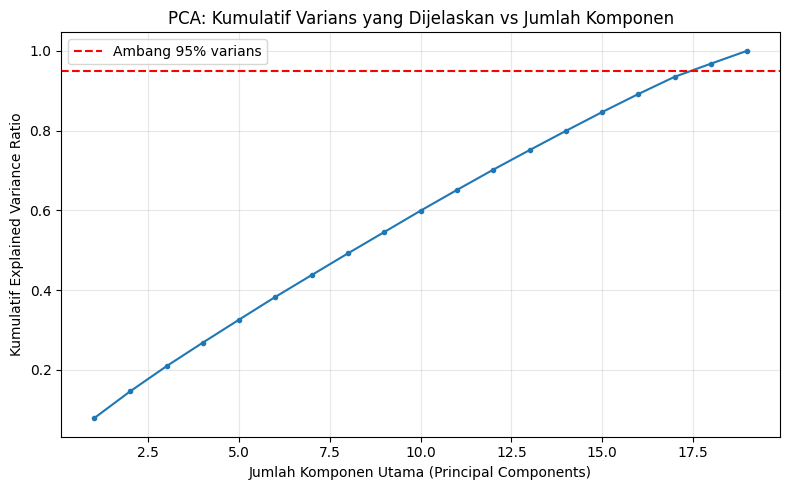

Jumlah komponen untuk mempertahankan >= 95% varians: 18 (dari semula 146 fitur/kata unik)


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# PCA bekerja pada matriks dense, sedangkan TF-IDF berbentuk sparse matrix -> ubah ke dense
tfidf_dense = tfidf_matrix.toarray()

# --- 4.1 Analisis Explained Variance ---
# Jumlah komponen maksimum dibatasi oleh min(jumlah dokumen, jumlah fitur)
n_komponen_maks = min(tfidf_dense.shape) - 1

pca_full = PCA(n_components=n_komponen_maks, random_state=42)
pca_full.fit(tfidf_dense)

variansi_kumulatif = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(variansi_kumulatif) + 1), variansi_kumulatif, marker='o', markersize=3)
plt.axhline(y=0.95, color='red', linestyle='--', label='Ambang 95% varians')
plt.xlabel('Jumlah Komponen Utama (Principal Components)')
plt.ylabel('Kumulatif Explained Variance Ratio')
plt.title('PCA: Kumulatif Varians yang Dijelaskan vs Jumlah Komponen')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Jumlah komponen minimum agar mempertahankan >= 95% varians
n_komponen_95 = int(np.argmax(variansi_kumulatif >= 0.95) + 1)
print(f"Jumlah komponen untuk mempertahankan >= 95% varians: {n_komponen_95} "
      f"(dari semula {tfidf_dense.shape[1]} fitur/kata unik)")


Total varians yang dijelaskan oleh 2 komponen pertama: 14.67%


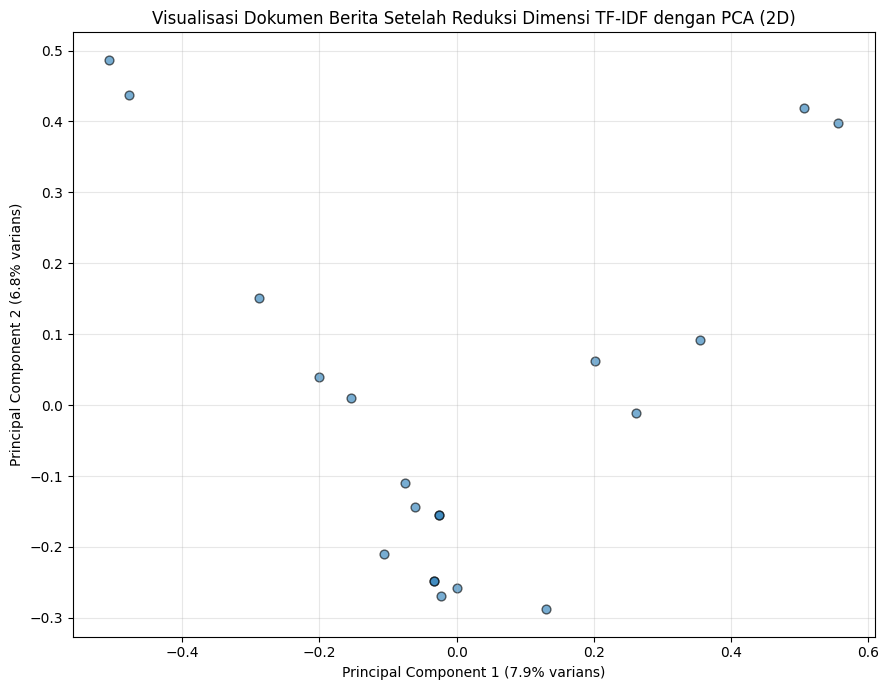

,PC1,PC2,Judul Berita
0,-0.075926,-0.109617,"Minum Kopi Memang Menyehatkan, Tapi Kalau Kele..."
1,-0.288450,0.150713,"Terungkap Lewat Studi, Kebiasaan Minum Panas T..."
2,0.000192,-0.257993,"Penampakan Gumpalan Rambut 1,5 Kg yang Diangka..."
3,-0.026257,-0.155327,Ternyata Manusia Masih Bisa Hidup Tanpa 5 Orga...
4,-0.105677,-0.210334,"Viral Makan Jahe Mentah Biar Nggak Flu, Dokter..."
5,-0.478010,0.436887,"Wanita Texas Rayakan Ultah ke-105, Ungkap Raha..."
6,-0.033301,-0.247561,"Jalan Cepat Vs Jumlah Langkah 10 Ribu Sehari, ..."
7,0.202181,0.061705,Video: Pengakses Healing 119 Capai 600 per Shi...
8,0.261338,-0.011288,Video: Kemenkes soal Siswi di Karo Diduga Hila...
9,0.354452,0.091929,Video Kemenkes: Kasus Bunuh Diri RI Naik Tiap ...


In [5]:
# --- 4.2 Reduksi ke 2 Dimensi untuk Visualisasi ---
pca_2d = PCA(n_components=2, random_state=42)
tfidf_pca_2d = pca_2d.fit_transform(tfidf_dense)

df_pca_2d = pd.DataFrame(tfidf_pca_2d, columns=['PC1', 'PC2'])
df_pca_2d['Judul Berita'] = df_berita['Judul Berita'].values

print("Total varians yang dijelaskan oleh 2 komponen pertama: {:.2f}%".format(
    100 * pca_2d.explained_variance_ratio_.sum()
))

plt.figure(figsize=(9, 7))
plt.scatter(df_pca_2d['PC1'], df_pca_2d['PC2'], alpha=0.6, edgecolor='k', s=40)
plt.xlabel(f'Principal Component 1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% varians)')
plt.ylabel(f'Principal Component 2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% varians)')
plt.title('Visualisasi Dokumen Berita Setelah Reduksi Dimensi TF-IDF dengan PCA (2D)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

df_pca_2d.head(10)


In [6]:
# --- 4.3 (Opsional) Reduksi ke n komponen yang mempertahankan >= 95% varians ---
# Fitur hasil reduksi ini yang biasanya dipakai sebagai input model ML selanjutnya
# (misalnya clustering atau klasifikasi berita), karena dimensinya jauh lebih kecil
# dibanding matriks TF-IDF asli namun tetap mempertahankan sebagian besar informasi.

pca_final = PCA(n_components=n_komponen_95, random_state=42)
tfidf_pca_final = pca_final.fit_transform(tfidf_dense)

print("Dimensi TF-IDF sebelum PCA :", tfidf_dense.shape)
print("Dimensi setelah PCA        :", tfidf_pca_final.shape)
print("Total varians dipertahankan: {:.2f}%".format(
    100 * pca_final.explained_variance_ratio_.sum()
))

df_pca_final = pd.DataFrame(
    tfidf_pca_final,
    columns=[f'PC{i+1}' for i in range(tfidf_pca_final.shape[1])],
    index=[f"Doc {i+1}" for i in range(tfidf_pca_final.shape[0])]
)
df_pca_final.head(10)


Dimensi TF-IDF sebelum PCA : (20, 146)
Dimensi setelah PCA        : (20, 18)
Total varians dipertahankan: 96.77%


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15,PC16,PC17,PC18
Doc 1,-0.075926,-0.109617,-0.082777,-0.271080,-0.074671,0.641504,-0.171827,0.107557,3.732636e-01,4.515245e-17,-0.068175,0.150550,-0.010585,-1.239302e-15,-0.481256,-0.005709,-0.036890,-0.002409
Doc 2,-0.288450,0.150713,0.138443,-0.327497,-0.018881,0.386564,-0.186740,0.043165,-6.353987e-15,-6.209772e-16,-0.042562,-0.100905,0.070488,2.263219e-15,0.671397,0.035123,0.156252,0.036999
Doc 3,0.000192,-0.257993,0.139158,0.088725,-0.094065,-0.065519,0.180810,0.789882,2.330395e-14,-2.342126e-14,0.286682,0.091191,-0.083604,-2.470968e-15,0.127593,-0.014390,-0.276412,0.029759
Doc 4,-0.026257,-0.155327,-0.147207,-0.015336,-0.054958,0.171186,0.507677,-0.095027,-2.841304e-01,7.071068e-01,-0.182405,-0.018522,0.057940,-1.859248e-15,-0.014769,0.013178,0.029492,0.005445
Doc 5,-0.105677,-0.210334,0.478427,-0.109516,-0.237237,-0.120402,-0.118303,-0.265890,-5.728000e-15,8.322729e-15,-0.103197,-0.470004,0.145771,2.171516e-15,-0.073458,-0.045439,-0.446462,0.002001
Doc 6,-0.478010,0.436887,0.176039,-0.051348,0.102359,-0.207443,0.142397,-0.016202,7.452379e-16,1.386649e-15,0.020992,-0.032807,-0.281097,-2.170995e-15,-0.255731,-0.006201,-0.062771,0.153333
Doc 7,-0.033301,-0.247561,-0.343703,-0.376696,0.194469,-0.346118,-0.146305,0.019941,7.011035e-16,-2.179595e-15,-0.042450,-0.006056,0.026406,-6.707304e-01,-0.007968,0.007936,0.019378,0.004319
Doc 8,0.202181,0.061705,-0.085017,0.043937,0.246794,0.152317,0.087550,-0.173440,-1.939835e-14,5.073482e-17,0.765270,-0.357270,0.152551,5.580073e-16,-0.087480,0.030389,0.135075,0.009233
Doc 9,0.261338,-0.011288,0.158613,0.201756,0.557794,0.106677,-0.057882,-0.065991,-3.102005e-15,2.988836e-15,-0.163313,0.118337,-0.073010,1.353065e-15,0.083502,-0.625593,-0.094964,0.072895
Doc 10,0.354452,0.091929,0.140574,0.157856,0.446631,0.069548,-0.065489,-0.047949,-1.411962e-15,2.612285e-15,-0.176760,0.113126,-0.053914,-1.290220e-15,0.051982,0.633143,-0.230491,-0.136931


### Ringkasan

| Tahap | Input | Output |
|---|---|---|
| Crawling | Halaman web Detik Health | `df_berita` (Judul Berita, Tautan) |
| Preprocessing | `df_berita['Judul Berita']` | `df_berita['teks_bersih']` |
| Ekstraksi Fitur | Korpus teks bersih | `vocabulary` (seluruh kata unik) |
| TF-IDF | Korpus + vocabulary | `tfidf_matrix` (dokumen x kata unik) |
| PCA | `tfidf_matrix` | Matriks berdimensi rendah (2D untuk visualisasi, atau *n* komponen untuk mempertahankan >=95% varians) |

Dengan pipeline ini, data berita mentah hasil *crawling* telah berhasil diubah menjadi representasi numerik (TF-IDF) yang siap digunakan untuk tahap lanjutan seperti *clustering* berita atau klasifikasi topik, dengan dimensi yang telah direduksi menggunakan PCA agar lebih efisien secara komputasi.